In [ ]:
!pip install numpy seaborn matplotlib pandas scikit-learn xgboost pycountry statsmodels


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


# TFM - Predictive analysis of suicide rates based on socioeconomic determinants and mental health prevalence

In [ ]:
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import warnings
import pycountry
import requests
import urllib3
urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)

# Statsmodels
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

# Scikit-learn
from sklearn.preprocessing import RobustScaler
from sklearn.decomposition import PCA
# Regression metrics — will be used in modelling section
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Configuration
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
%matplotlib inline
np.random.seed(42)

pd.set_option('display.width', 1000)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)

## Preparing the base database
Mental illnesses prevalence extracted from Kaggle

In [ ]:
# EU countries list since they are the ones of interest in this analysis
EU_countries_iso = [
    "DEU",
    "AUT",
    "BEL",
    "BGR",
    "CYP",
    "HRV",
    "DNK",
    "SVK",
    "SVN",
    "ESP",
    "EST",
    "FIN",
    "FRA",
    "GRC",
    "HUN",
    "IRL",
    "ITA",
    "LVA",
    "LTU",
    "LUX",
    "MLT",
    "NLD",
    "POL",
    "PRT",
    "CZE",
    "ROU",
    "SWE",
]

# Mapping dictionary based on the ISO alpha-3 codes for the EU
EU_regions = {
    "DEU": "Western Europe/Nordics",
    "FRA": "Western Europe/Nordics",
    "NLD": "Western Europe/Nordics",
    "BEL": "Western Europe/Nordics",
    "LUX": "Western Europe/Nordics",
    "AUT": "Western Europe/Nordics",
    "DNK": "Western Europe/Nordics",
    "FIN": "Western Europe/Nordics",
    "SWE": "Western Europe/Nordics",
    "IRL": "Western Europe/Nordics",
    "ESP": "Mediterranean",
    "ITA": "Mediterranean",
    "PRT": "Mediterranean",
    "GRC": "Mediterranean",
    "CYP": "Mediterranean",
    "MLT": "Mediterranean",
    "POL": "Eastern Europe",
    "CZE": "Eastern Europe",
    "SVK": "Eastern Europe",
    "HUN": "Eastern Europe",
    "ROU": "Eastern Europe",
    "BGR": "Eastern Europe",
    "SVN": "Eastern Europe",
    "HRV": "Eastern Europe",
    "EST": "Baltics",
    "LVA": "Baltics",
    "LTU": "Baltics",
}

social_economic_features = [
    "Suicide rate",  # Objective variable
    "GDP per capita",
    "Unemployment rate (%)",
    "Health expenditure (% GDP)",
    "Population",
    "Urban population (%)",
    "Physicians per 100000",
    "Gini index",
    "Internet users (% of population)",
]

health_related_features = [
    "Suicide rate",  # Objective variable
    "Alcohol use disorders",
    "Alzheimer's disease and other dementias",
    "Anxiety disorders",
    "Attention-deficit/hyperactivity disorder",
    "Autism spectrum disorders",
    "Bipolar disorder",
    "Conduct disorder",
    "Depressive disorders",
    "Schizophrenia",
    "Drug use disorders",
    # Eating disorders excluded — high VIF (12.3), dropped before modelling
]


ID_COLS = ["Country", "Code", "Year", "Region"]
TARGET = "Suicide rate"


# Function to obtain the ISO-Alpha 3 code of the country
def country_code(geo_name):
    """
    Looks up the ISO-Alpha 3 country code based on a given country text name.

    Parameters:
    -----------
    geo_name : str
        The textual name of the country (e.g., "Austria", "Greece").

    Returns:
    --------
    str or None
        The 3-letter ISO code if found (e.g., "AUT"), otherwise None.
    """
    try:
        pais = pycountry.countries.lookup(geo_name)
        return pais.alpha_3
    except LookupError:
        return None


# Function to graph the evolution of a suicide rate per country
def suicide_evolution_graph(dataframe, country_code, country_name):
    """
    Generates and displays a line plot showing the chronological evolution
    of the suicide rate for a specific country.

    Parameters:
    -----------
    dataframe : pd.DataFrame
        The consolidated master dataframe containing 'Code', 'Year', and 'Suicide rate'.
    country_code : str
        The 3-letter ISO code of the target country (e.g., "GRC").
    country_name : str
        The common name of the country to display in the plot title (e.g., "Greece").

    Returns:
    --------
    None
        Renders a matplotlib plot.
    """
    # Filtering dataframe for a specific country code
    df_country = dataframe[dataframe["Code"] == country_code].sort_values("Year")

    # Creating the figure and sizing it
    plt.figure(figsize=(12, 6))

    # Plotting the line with the values for the specified country
    plt.plot(
        df_country["Year"],
        df_country["Suicide rate"],
        color="#1f77b4",
        linestyle="-",
        marker="o",
        linewidth=2.5,
    )

    # Beauty personalization
    plt.title(
        f"Suicide rate evolution in {country_name}",
        fontsize=16,
        fontweight="bold",
        pad=15,
    )
    plt.xlabel("Year", fontsize=12)
    plt.ylabel("Rate per 100,000 inhabitants", fontsize=12)

    # Showing every two years values in X axis
    min_year, max_year = int(df_country["Year"].min()), int(df_country["Year"].max())
    plt.xticks(range(min_year, max_year + 1, 2))

    # Adjusting margins and showing the graph
    plt.tight_layout()
    plt.show()

In [ ]:
# ==============================================================================
# DATA PIPELINE STEP 1: IHME Mental Health Prevalence Base
# Database was filtered on gathering the data to only have EU countries
# ==============================================================================

# Base data from IHME
base_data = pd.read_csv("./data/IHME-GBD_2023_DATA-b62eec84-1.csv")
base_data["Code"] = base_data["location_name"].apply(country_code)
base_data_short = base_data[["location_name", "Code", "year", "cause_name", "val"]]
base_data_pivot = base_data_short.pivot(
    index=["location_name", "Code", "year"], columns="cause_name", values="val"
)
base_data_pivot.columns.name = None
base_data_pivot = base_data_pivot.reset_index()
df_base = base_data_pivot.rename(columns={"location_name": "Country", "year": "Year"})
df_base = df_base.drop(columns=["All causes"])
df = df_base[df_base["Year"] >= 2000].copy()
df

,Country,Code,Year,Alcohol use disorders,Alzheimer's disease and other dementias,Anxiety disorders,Attention-deficit/hyperactivity disorder,Autism spectrum disorders,Bipolar disorder,Conduct disorder,Depressive disorders,Drug use disorders,Eating disorders,Schizophrenia
6,Austria,AUT,2000,3191.951091,1132.966544,4024.482195,1175.534494,721.252486,720.168715,395.555429,2408.933392,881.662224,479.043042,340.766068
7,Austria,AUT,2001,3193.762279,1143.969355,4046.938653,1173.433463,723.015405,719.736433,394.027233,2414.230764,875.548127,479.489990,342.045193
8,Austria,AUT,2002,3196.670699,1158.019381,4069.554739,1173.688637,724.906163,717.163393,390.398108,2420.619752,867.476203,479.784032,343.374835
9,Austria,AUT,2003,3201.329520,1163.789032,4102.701811,1174.340827,727.316029,714.040173,385.443904,2425.310908,859.486814,480.160291,344.800007
10,Austria,AUT,2004,3206.603569,1163.505776,4147.044336,1173.529004,729.994711,711.859272,380.592234,2428.414977,853.367328,480.506984,346.150489
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
805,Sweden,SWE,2019,2897.498890,1355.018452,4681.325510,837.347190,1009.227065,691.369692,389.980052,4071.965808,930.633756,462.785702,285.952236
806,Sweden,SWE,2020,2776.695254,1371.340819,5729.796753,838.083163,1009.305732,690.913455,393.404674,4978.454347,934.750734,463.972841,285.502357
807,Sweden,SWE,2021,2731.449349,1377.436844,5774.235422,839.038586,1009.554676,687.203737,396.199380,4601.316049,938.469081,467.280088,285.717568
808,Sweden,SWE,2022,2709.865933,1410.557957,6240.680967,838.776139,1008.378063,683.488721,397.687661,4888.626199,941.071338,469.844997,285.905098


## World Bank socioeconomic indicators
Indicators chosen:
- GDP per capita (USD).
- Unemployment rate.
- Health expenditure per country (percentage of GDP).
- Population per country.
- Gini index. Measures the income inequalities. A greater unequality correlates to a greater psychosocial stress.
- Urban population (%). Allows to analyse if the urban environment (isolation, low resources) affects the rate.
- Physicians per 100,000 inhabitants. Measures the health system capability. The lower the rate, the lower the access to psychiatrists.
- Digital connectivity. Internet access could either be an issue for mental health or a network for support.

In [ ]:
# ==============================================================================
# DATA PIPELINE STEP 2: Enhanced World Bank API Extraction
# ==============================================================================

# Defining the parameters in the URL of the API v2
INDICATORS = {
    "NY.GDP.PCAP.CD": "GDP per capita",
    "SL.UEM.TOTL.ZS": "Unemployment rate (%)",
    "SH.XPD.CHEX.GD.ZS": "Health expenditure (% GDP)",
    "SP.POP.TOTL": "Population",
    "SI.POV.GINI": "Gini index",
    "SP.URB.TOTL.IN.ZS": "Urban population (%)",
    "SH.MED.PHYS.ZS": "Physicians per 1000",
    "IT.NET.USER.ZS": "Internet users (% of population)",
}
REGION = "ALL"

df_features = df.copy()

for code, column_name in INDICATORS.items():
    url_wb = f"http://api.worldbank.org/v2/country/{REGION}/indicator/{code}?format=json&per_page=10000&date=2000:2026"

    # SSL certificate verification disabled for local network compatibility.
    # Remove verify=False if running in a production or public environment.
    response = requests.get(url_wb, verify=False)

    if response.status_code == 200:
        # World Bank returns a list where [0] is paging and [1] is the actual data
        raw_data = response.json()[1]

        # Converting to DataFrame
        df_wb = pd.DataFrame(raw_data)

        # It is a nested JSON, where country is a dictionary, which needs to be flattened:
        df_wb["Country"] = df_wb["country"].apply(lambda x: x["value"])
        df_wb["Code"] = df_wb["countryiso3code"].str.upper()
        df_wb["Year"] = df_wb["date"].astype(int)
        df_wb[column_name] = df_wb["value"]

        # Cleaning and ordering
        df_final_wb = df_wb[["Country", "Code", "Year", column_name]].dropna()

        df_final_eu = df_final_wb[df_final_wb["Code"].isin(EU_countries_iso)].copy()

        df_features = pd.merge(
            df_features,
            df_final_eu[["Code", "Year", column_name]],
            on=["Code", "Year"],
            how="left",
        )

        print(
            f"DataFrame '{column_name}' successfully created. Rows retrieved: {len(df_final_eu)}."
        )
        print("-" * 50)

if "Physicians per 1000" in df_features.columns:
    df_features["Physicians per 100000"] = df_features["Physicians per 1000"] * 100
    df_features.drop(columns=["Physicians per 1000"], inplace=True)

df_features

DataFrame 'GDP per capita' successfully created. Rows retrieved: 675.
--------------------------------------------------
DataFrame 'Unemployment rate (%)' successfully created. Rows retrieved: 702.
--------------------------------------------------
DataFrame 'Health expenditure (% GDP)' successfully created. Rows retrieved: 663.
--------------------------------------------------
DataFrame 'Population' successfully created. Rows retrieved: 675.
--------------------------------------------------
DataFrame 'Gini index' successfully created. Rows retrieved: 589.
--------------------------------------------------
DataFrame 'Urban population (%)' successfully created. Rows retrieved: 675.
--------------------------------------------------
DataFrame 'Physicians per 1000' successfully created. Rows retrieved: 616.
--------------------------------------------------
DataFrame 'Internet users (% of population)' successfully created. Rows retrieved: 678.
-------------------------------------------

,Country,Code,Year,Alcohol use disorders,Alzheimer's disease and other dementias,Anxiety disorders,Attention-deficit/hyperactivity disorder,Autism spectrum disorders,Bipolar disorder,Conduct disorder,Depressive disorders,Drug use disorders,Eating disorders,Schizophrenia,GDP per capita,Unemployment rate (%),Health expenditure (% GDP),Population,Gini index,Urban population (%),Internet users (% of population),Physicians per 100000
0,Austria,AUT,2000,3191.951091,1132.966544,4024.482195,1175.534494,721.252486,720.168715,395.555429,2408.933392,881.662224,479.043042,340.766068,24487.297469,4.687,9.389345,8011566.0,29.0,66.769024,33.730133,387.6
1,Austria,AUT,2001,3193.762279,1143.969355,4046.938653,1173.433463,723.015405,719.736433,394.027233,2414.230764,875.548127,479.489990,342.045193,24430.495983,4.007,9.452435,8042293.0,NaN,66.840816,39.185450,398.9
2,Austria,AUT,2002,3196.670699,1158.019381,4069.554739,1173.688637,724.906163,717.163393,390.398108,2420.619752,867.476203,479.784032,343.374835,26334.862215,4.852,9.591399,8081957.0,NaN,66.888746,36.560000,406.0
3,Austria,AUT,2003,3201.329520,1163.789032,4102.701811,1174.340827,727.316029,714.040173,385.443904,2425.310908,859.486814,480.160291,344.800007,32110.115966,4.779,9.698442,8121423.0,29.5,66.926357,42.700000,414.4
4,Austria,AUT,2004,3206.603569,1163.505776,4147.044336,1173.529004,729.994711,711.859272,380.592234,2428.414977,853.367328,480.506984,346.150489,36614.250653,5.969,9.815324,8171966.0,29.8,66.955861,54.280000,423.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
643,Sweden,SWE,2019,2897.498890,1355.018452,4681.325510,837.347190,1009.227065,691.369692,389.980052,4071.965808,930.633756,462.785702,285.952236,51648.989282,6.833,10.934443,10278887.0,29.3,87.708842,94.493443,428.8
644,Sweden,SWE,2020,2776.695254,1371.340819,5729.796753,838.083163,1009.305732,690.913455,393.404674,4978.454347,934.750734,463.972841,285.502357,52568.572698,8.291,11.424587,10353442.0,28.9,87.942405,94.539431,432.2
645,Sweden,SWE,2021,2731.449349,1377.436844,5774.235422,839.038586,1009.554676,687.203737,396.199380,4601.316049,938.469081,467.280088,285.717568,60647.541637,8.803,11.230136,10415811.0,29.8,88.174165,94.670316,440.8
646,Sweden,SWE,2022,2709.865933,1410.557957,6240.680967,838.776139,1008.378063,683.488721,397.687661,4888.626199,941.071338,469.844997,285.905098,54836.890724,7.417,10.855057,10486941.0,31.6,88.403858,95.009703,NaN


## Preparing the WHO database for the join with the master database (predictive variable: suicide rate)

In [ ]:
# ==============================================================================
# DATA PIPELINE STEP 3: WHO API Suicide Rates Join
# ==============================================================================

# Official indicator from the WHO for the mortality rate due to self-harm
INDICATOR = "SDGSUICIDE"
url = f"https://ghoapi.azureedge.net/api/{INDICATOR}"

print("Downloading dataset from the WHO API.")
response = requests.get(url, verify=False)

if response.status_code == 200:
    data = response.json()["value"]

    # Testing if the response returned any value.
    if len(data) == 0:
        print("The API responded but did not find any data for this indicator.")
    else:
        df_raw = pd.DataFrame(data)

        # Filtering to only keep BTSX (both sexes) and YEARSALL (all year groups).
        df_filtered = df_raw[
            (df_raw["Dim1"] == "SEX_BTSX") & (df_raw["Dim2"] == "AGEGROUP_YEARSALL")
        ].copy()

        # Selecting the columns of interest
        interest_columns = ["SpatialDim", "TimeDim", "NumericValue"]
        df_clean = df_filtered[interest_columns].copy()

        # Renaming to match the rest of the datasets
        df_clean.columns = ["Code", "Year", "Suicide rate"]

        # Sort chronologically by country and year
        df_clean = df_clean.sort_values(by=["Code", "Year"])

else:
    print(f"Error trying to connect with the API. Status code: {response.status_code}")

df_complete = pd.merge(
    df_features,
    df_clean[["Code", "Year", "Suicide rate"]],
    on=["Code", "Year"],
    how="left",
)

# Sort by country and year to ensure correct chronological ordering
# before interpolation and downstream groupby operations
df_complete = df_complete.sort_values(by=["Country", "Year"]).reset_index(drop=True)

# Separate the data set between the real world (not-known suicide rates) and the rest of the data
df_development = df_complete[df_complete["Year"] <= 2021].copy()
# Retain df_real_world for reference only — WHO data for 2022-2023 is unavailable
# so this dataset has no suicide rate labels and is not used in modelling.
df_real_world = df_complete[df_complete["Year"] >= 2022].copy()

display(df_development.head())

,Country,Code,Year,Alcohol use disorders,Alzheimer's disease and other dementias,Anxiety disorders,Attention-deficit/hyperactivity disorder,Autism spectrum disorders,Bipolar disorder,Conduct disorder,Depressive disorders,Drug use disorders,Eating disorders,Schizophrenia,GDP per capita,Unemployment rate (%),Health expenditure (% GDP),Population,Gini index,Urban population (%),Internet users (% of population),Physicians per 100000,Suicide rate
0,Austria,AUT,2000,3191.951091,1132.966544,4024.482195,1175.534494,721.252486,720.168715,395.555429,2408.933392,881.662224,479.043042,340.766068,24487.297469,4.687,9.389345,8011566.0,29.0,66.769024,33.730133,387.6,19.753390
1,Austria,AUT,2001,3193.762279,1143.969355,4046.938653,1173.433463,723.015405,719.736433,394.027233,2414.230764,875.548127,479.489990,342.045193,24430.495983,4.007,9.452435,8042293.0,NaN,66.840816,39.185450,398.9,18.508048
2,Austria,AUT,2002,3196.670699,1158.019381,4069.554739,1173.688637,724.906163,717.163393,390.398108,2420.619752,867.476203,479.784032,343.374835,26334.862215,4.852,9.591399,8081957.0,NaN,66.888746,36.560000,406.0,19.413281
3,Austria,AUT,2003,3201.329520,1163.789032,4102.701811,1174.340827,727.316029,714.040173,385.443904,2425.310908,859.486814,480.160291,344.800007,32110.115966,4.779,9.698442,8121423.0,29.5,66.926357,42.700000,414.4,17.989560
4,Austria,AUT,2004,3206.603569,1163.505776,4147.044336,1173.529004,729.994711,711.859272,380.592234,2428.414977,853.367328,480.506984,346.150489,36614.250653,5.969,9.815324,8171966.0,29.8,66.955861,54.280000,423.2,17.383069


In [ ]:
# ==============================================================================
# 1. DESCRIPTIVE STATISTICS
# ==============================================================================
print("Master Dataset Summary Statistics")
display(df_development.describe().T)

print("\nMissing values")
print(df_development.isnull().sum())

Master Dataset Summary Statistics


,count,mean,std,min,25%,50%,75%,max
Year,594.0,2.010500e+03,6.349636e+00,2000.000000,2.005000e+03,2.010500e+03,2.016000e+03,2.021000e+03
Alcohol use disorders,594.0,2.640863e+03,6.501545e+02,1468.353858,2.154470e+03,2.638039e+03,3.166213e+03,3.930876e+03
Alzheimer's disease and other dementias,594.0,1.162906e+03,3.505339e+02,615.594485,9.072604e+02,1.109865e+03,1.317172e+03,2.490327e+03
Anxiety disorders,594.0,5.060044e+03,1.514067e+03,2850.328655,3.934236e+03,4.670571e+03,5.770123e+03,1.142191e+04
Attention-deficit/hyperactivity disorder,594.0,7.675910e+02,3.598561e+02,248.480691,4.405874e+02,7.954818e+02,9.792250e+02,1.722195e+03
Autism spectrum disorders,594.0,6.979302e+02,1.188224e+02,497.467873,5.765145e+02,7.303758e+02,7.675203e+02,1.011089e+03
Bipolar disorder,594.0,6.507963e+02,8.939936e+01,488.696921,5.619674e+02,6.689073e+02,7.169895e+02,8.472123e+02
Conduct disorder,594.0,3.712084e+02,5.047307e+01,281.621053,3.309906e+02,3.666408e+02,4.003332e+02,5.418604e+02
Depressive disorders,594.0,3.332831e+03,7.327951e+02,2229.578134,2.753071e+03,3.272819e+03,3.777113e+03,6.698489e+03
Drug use disorders,594.0,8.564169e+02,2.555415e+02,282.936650,6.690521e+02,8.318342e+02,9.782403e+02,1.852197e+03



Missing values
Country                                      0
Code                                         0
Year                                         0
Alcohol use disorders                        0
Alzheimer's disease and other dementias      0
Anxiety disorders                            0
Attention-deficit/hyperactivity disorder     0
Autism spectrum disorders                    0
Bipolar disorder                             0
Conduct disorder                             0
Depressive disorders                         0
Drug use disorders                           0
Eating disorders                             0
Schizophrenia                                0
GDP per capita                               0
Unemployment rate (%)                        0
Health expenditure (% GDP)                   0
Population                                   0
Gini index                                  54
Urban population (%)                         0
Internet users (% of population)            

## Inspecting missing values: Gini index and Physicians per 100,000
To have a clear idea of which value imputation method to use

In [ ]:
print(
    df_development[
        df_development["Gini index"].isna()
        | df_development["Physicians per 100000"].isna()
    ]
)

         Country Code  Year  Alcohol use disorders  Alzheimer's disease and other dementias  Anxiety disorders  Attention-deficit/hyperactivity disorder  Autism spectrum disorders  Bipolar disorder  Conduct disorder  Depressive disorders  Drug use disorders  Eating disorders  Schizophrenia  GDP per capita  Unemployment rate (%)  Health expenditure (% GDP)  Population  Gini index  Urban population (%)  Internet users (% of population)  Physicians per 100000  Suicide rate
1        Austria  AUT  2001            3193.762279                              1143.969355        4046.938653                               1173.433463                 723.015405        719.736433        394.027233           2414.230764          875.548127        479.489990     342.045193    24430.495983                  4.007                    9.452435   8042293.0         NaN             66.840816                         39.185450                  398.9     18.508048
2        Austria  AUT  2002            3196.670699

## Missing values imputation
Linear interpolation chosen since there are consecutive years missing.

In [ ]:
# Define the columns with missing values
features_with_NaN = ["Gini index", "Physicians per 100000"]

for col in features_with_NaN:
    # Linear interpolation within each country (only fills between known points)
    df_development[col] = df_development.groupby("Country")[col].transform(
        lambda x: x.interpolate(method="linear", limit_direction="both")
    )

print("Remaining NaNs after interpolation:")
print(df_development[features_with_NaN].isnull().sum())

display(df_development.head())
print(df_development.isnull().sum())

Remaining NaNs after interpolation:
Gini index               0
Physicians per 100000    0
dtype: int64


,Country,Code,Year,Alcohol use disorders,Alzheimer's disease and other dementias,Anxiety disorders,Attention-deficit/hyperactivity disorder,Autism spectrum disorders,Bipolar disorder,Conduct disorder,Depressive disorders,Drug use disorders,Eating disorders,Schizophrenia,GDP per capita,Unemployment rate (%),Health expenditure (% GDP),Population,Gini index,Urban population (%),Internet users (% of population),Physicians per 100000,Suicide rate
0,Austria,AUT,2000,3191.951091,1132.966544,4024.482195,1175.534494,721.252486,720.168715,395.555429,2408.933392,881.662224,479.043042,340.766068,24487.297469,4.687,9.389345,8011566.0,29.000000,66.769024,33.730133,387.6,19.753390
1,Austria,AUT,2001,3193.762279,1143.969355,4046.938653,1173.433463,723.015405,719.736433,394.027233,2414.230764,875.548127,479.489990,342.045193,24430.495983,4.007,9.452435,8042293.0,29.166667,66.840816,39.185450,398.9,18.508048
2,Austria,AUT,2002,3196.670699,1158.019381,4069.554739,1173.688637,724.906163,717.163393,390.398108,2420.619752,867.476203,479.784032,343.374835,26334.862215,4.852,9.591399,8081957.0,29.333333,66.888746,36.560000,406.0,19.413281
3,Austria,AUT,2003,3201.329520,1163.789032,4102.701811,1174.340827,727.316029,714.040173,385.443904,2425.310908,859.486814,480.160291,344.800007,32110.115966,4.779,9.698442,8121423.0,29.500000,66.926357,42.700000,414.4,17.989560
4,Austria,AUT,2004,3206.603569,1163.505776,4147.044336,1173.529004,729.994711,711.859272,380.592234,2428.414977,853.367328,480.506984,346.150489,36614.250653,5.969,9.815324,8171966.0,29.800000,66.955861,54.280000,423.2,17.383069


Country                                     0
Code                                        0
Year                                        0
Alcohol use disorders                       0
Alzheimer's disease and other dementias     0
Anxiety disorders                           0
Attention-deficit/hyperactivity disorder    0
Autism spectrum disorders                   0
Bipolar disorder                            0
Conduct disorder                            0
Depressive disorders                        0
Drug use disorders                          0
Eating disorders                            0
Schizophrenia                               0
GDP per capita                              0
Unemployment rate (%)                       0
Health expenditure (% GDP)                  0
Population                                  0
Gini index                                  0
Urban population (%)                        0
Internet users (% of population)            0
Physicians per 100000             

## Suicide rate evolution — country spotlights
The following plots highlight the two extremes of the EU distribution and a mid-range reference country, contextualising the outliers identified later.

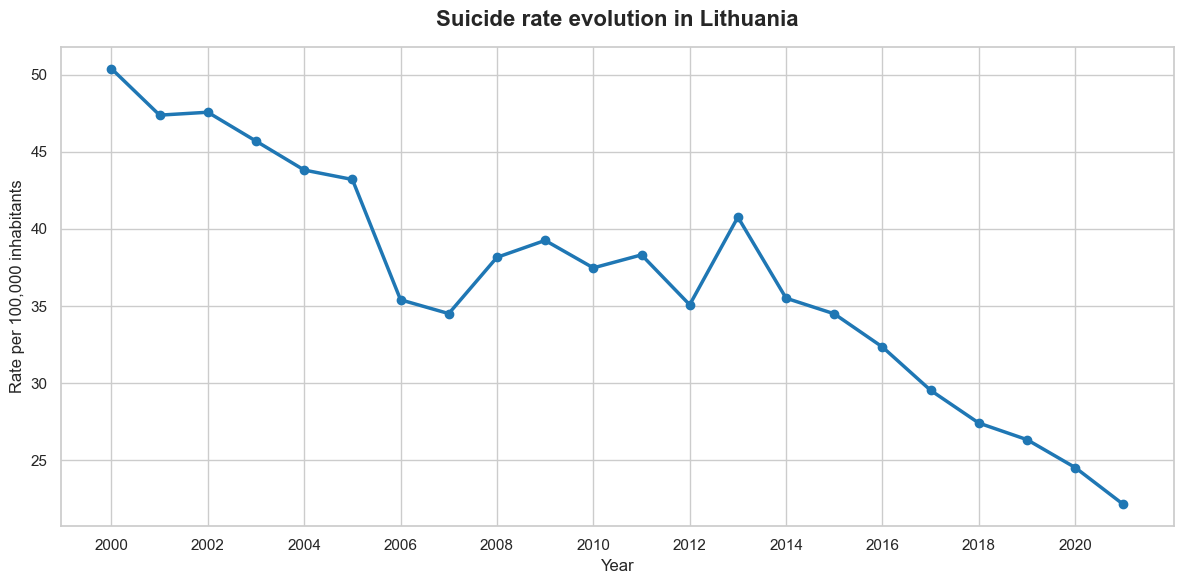

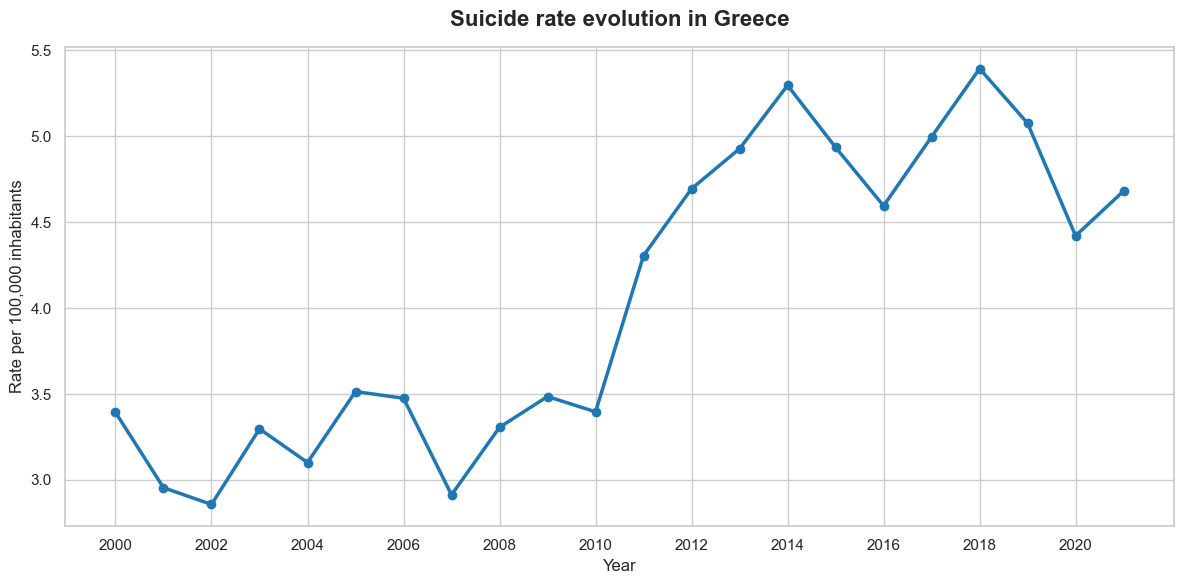

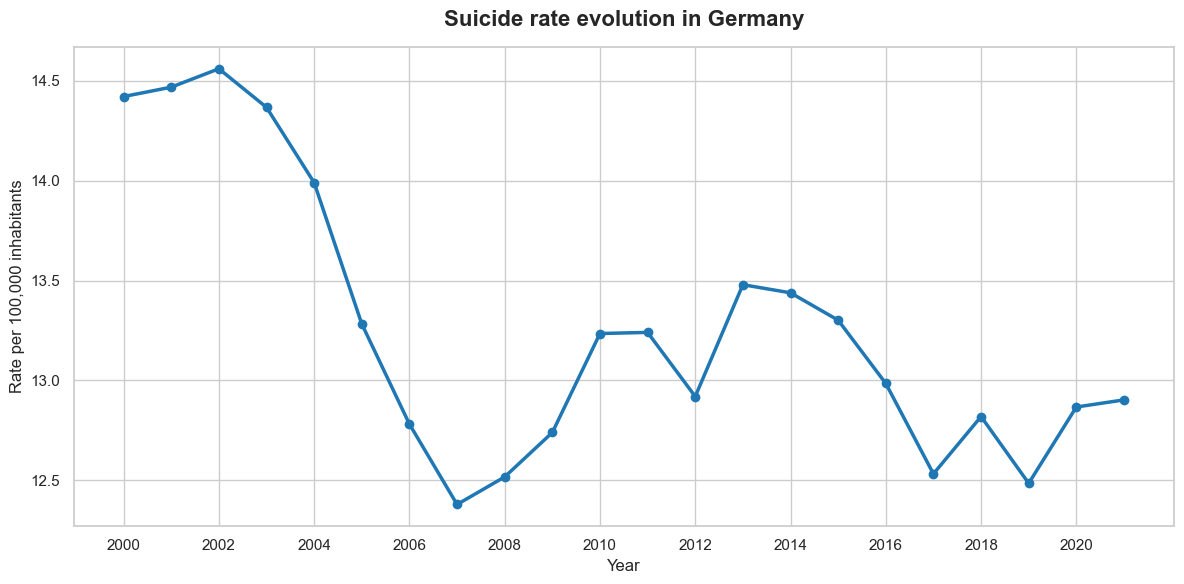

In [ ]:
# Highest average suicide rate in the EU
suicide_evolution_graph(df_development, "LTU", "Lithuania")

# Lowest average suicide rate in the EU
suicide_evolution_graph(df_development, "GRC", "Greece")

# A mid-range country for reference
suicide_evolution_graph(df_development, "DEU", "Germany")

## Suicide rate trends by EU region (2000–2021)

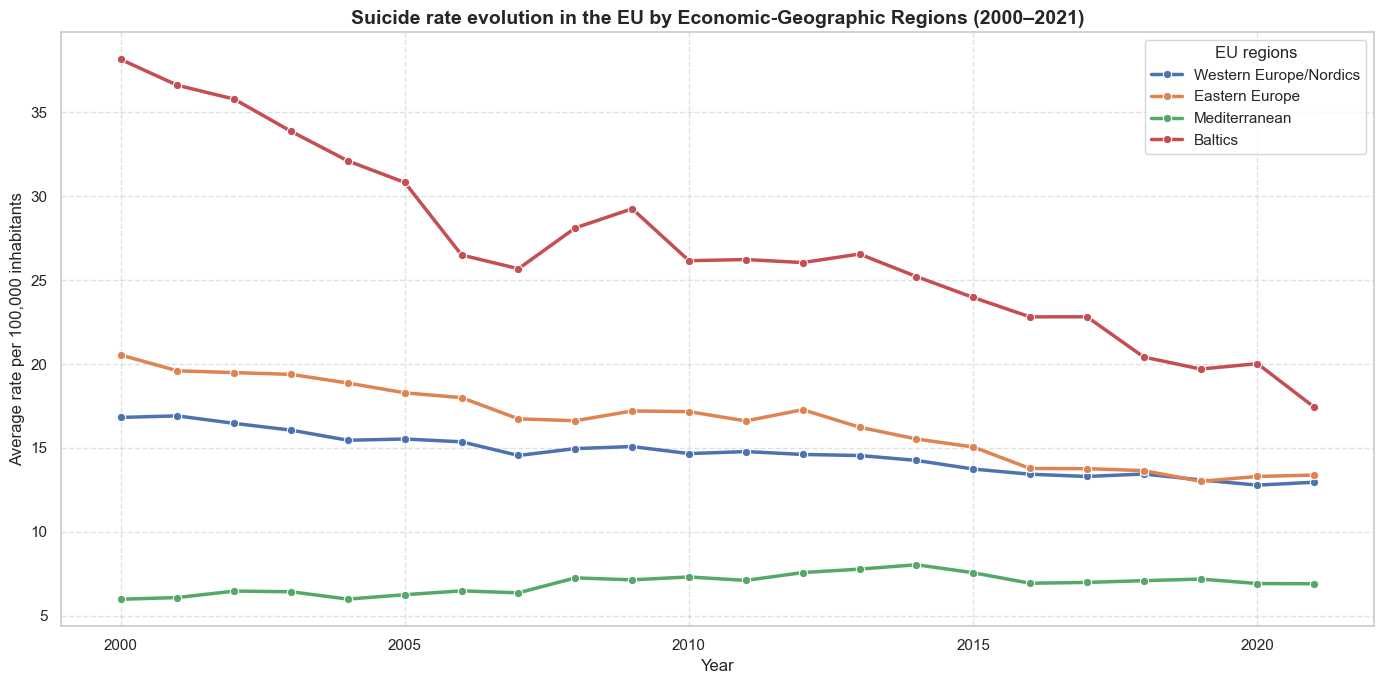

In [ ]:
df_development["Region"] = df_development["Code"].map(EU_regions)

# Graphing the time evolution per region
plt.figure(figsize=(14, 7))
sns.lineplot(
    data=df_development,
    x="Year",
    y="Suicide rate",
    hue="Region",
    marker="o",
    linewidth=2.5,
    errorbar=None,
)

plt.title(
    "Suicide rate evolution in the EU by Economic-Geographic Regions (2000–2021)",
    fontsize=14,
    fontweight="bold",
)
plt.xlabel("Year")
plt.ylabel("Average rate per 100,000 inhabitants")
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(title="EU regions")
plt.tight_layout()
plt.show()

## Cross-country distribution analysis

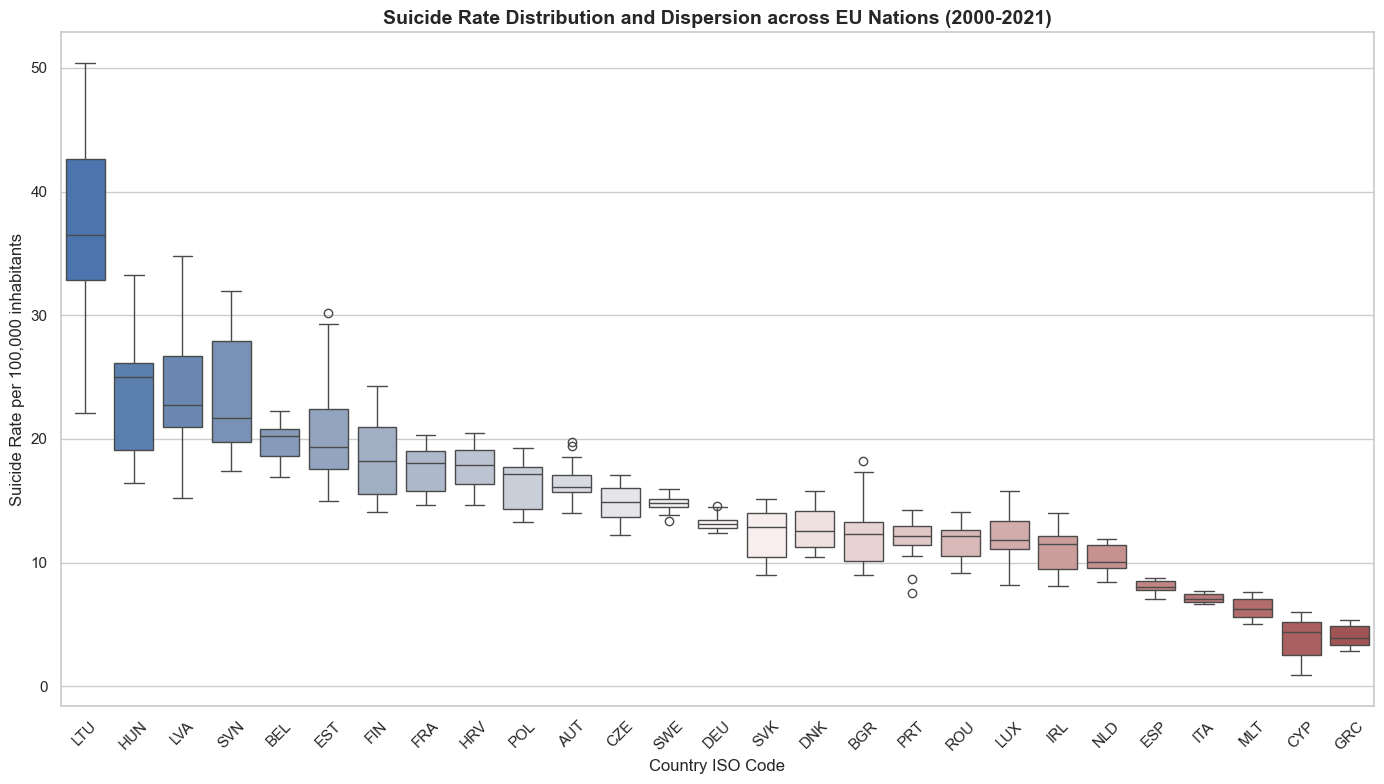

In [ ]:
# ==============================================================================
# CROSS-COUNTRY DISTRIBUTION ANALYSIS
# ==============================================================================
# Distribution of Suicide Rates across different EU nations
plt.figure(figsize=(14, 8))
sns.boxplot(
    data=df_development,
    x="Code",
    y="Suicide rate",
    palette="vlag",
    order=df_development.groupby("Code")["Suicide rate"]
    .median()
    .sort_values(ascending=False)
    .index,
)
plt.title(
    "Suicide Rate Distribution and Dispersion across EU Nations (2000-2021)",
    fontsize=14,
    fontweight="bold",
)
plt.xlabel("Country ISO Code")
plt.ylabel("Suicide Rate per 100,000 inhabitants")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Feature distribution analysis

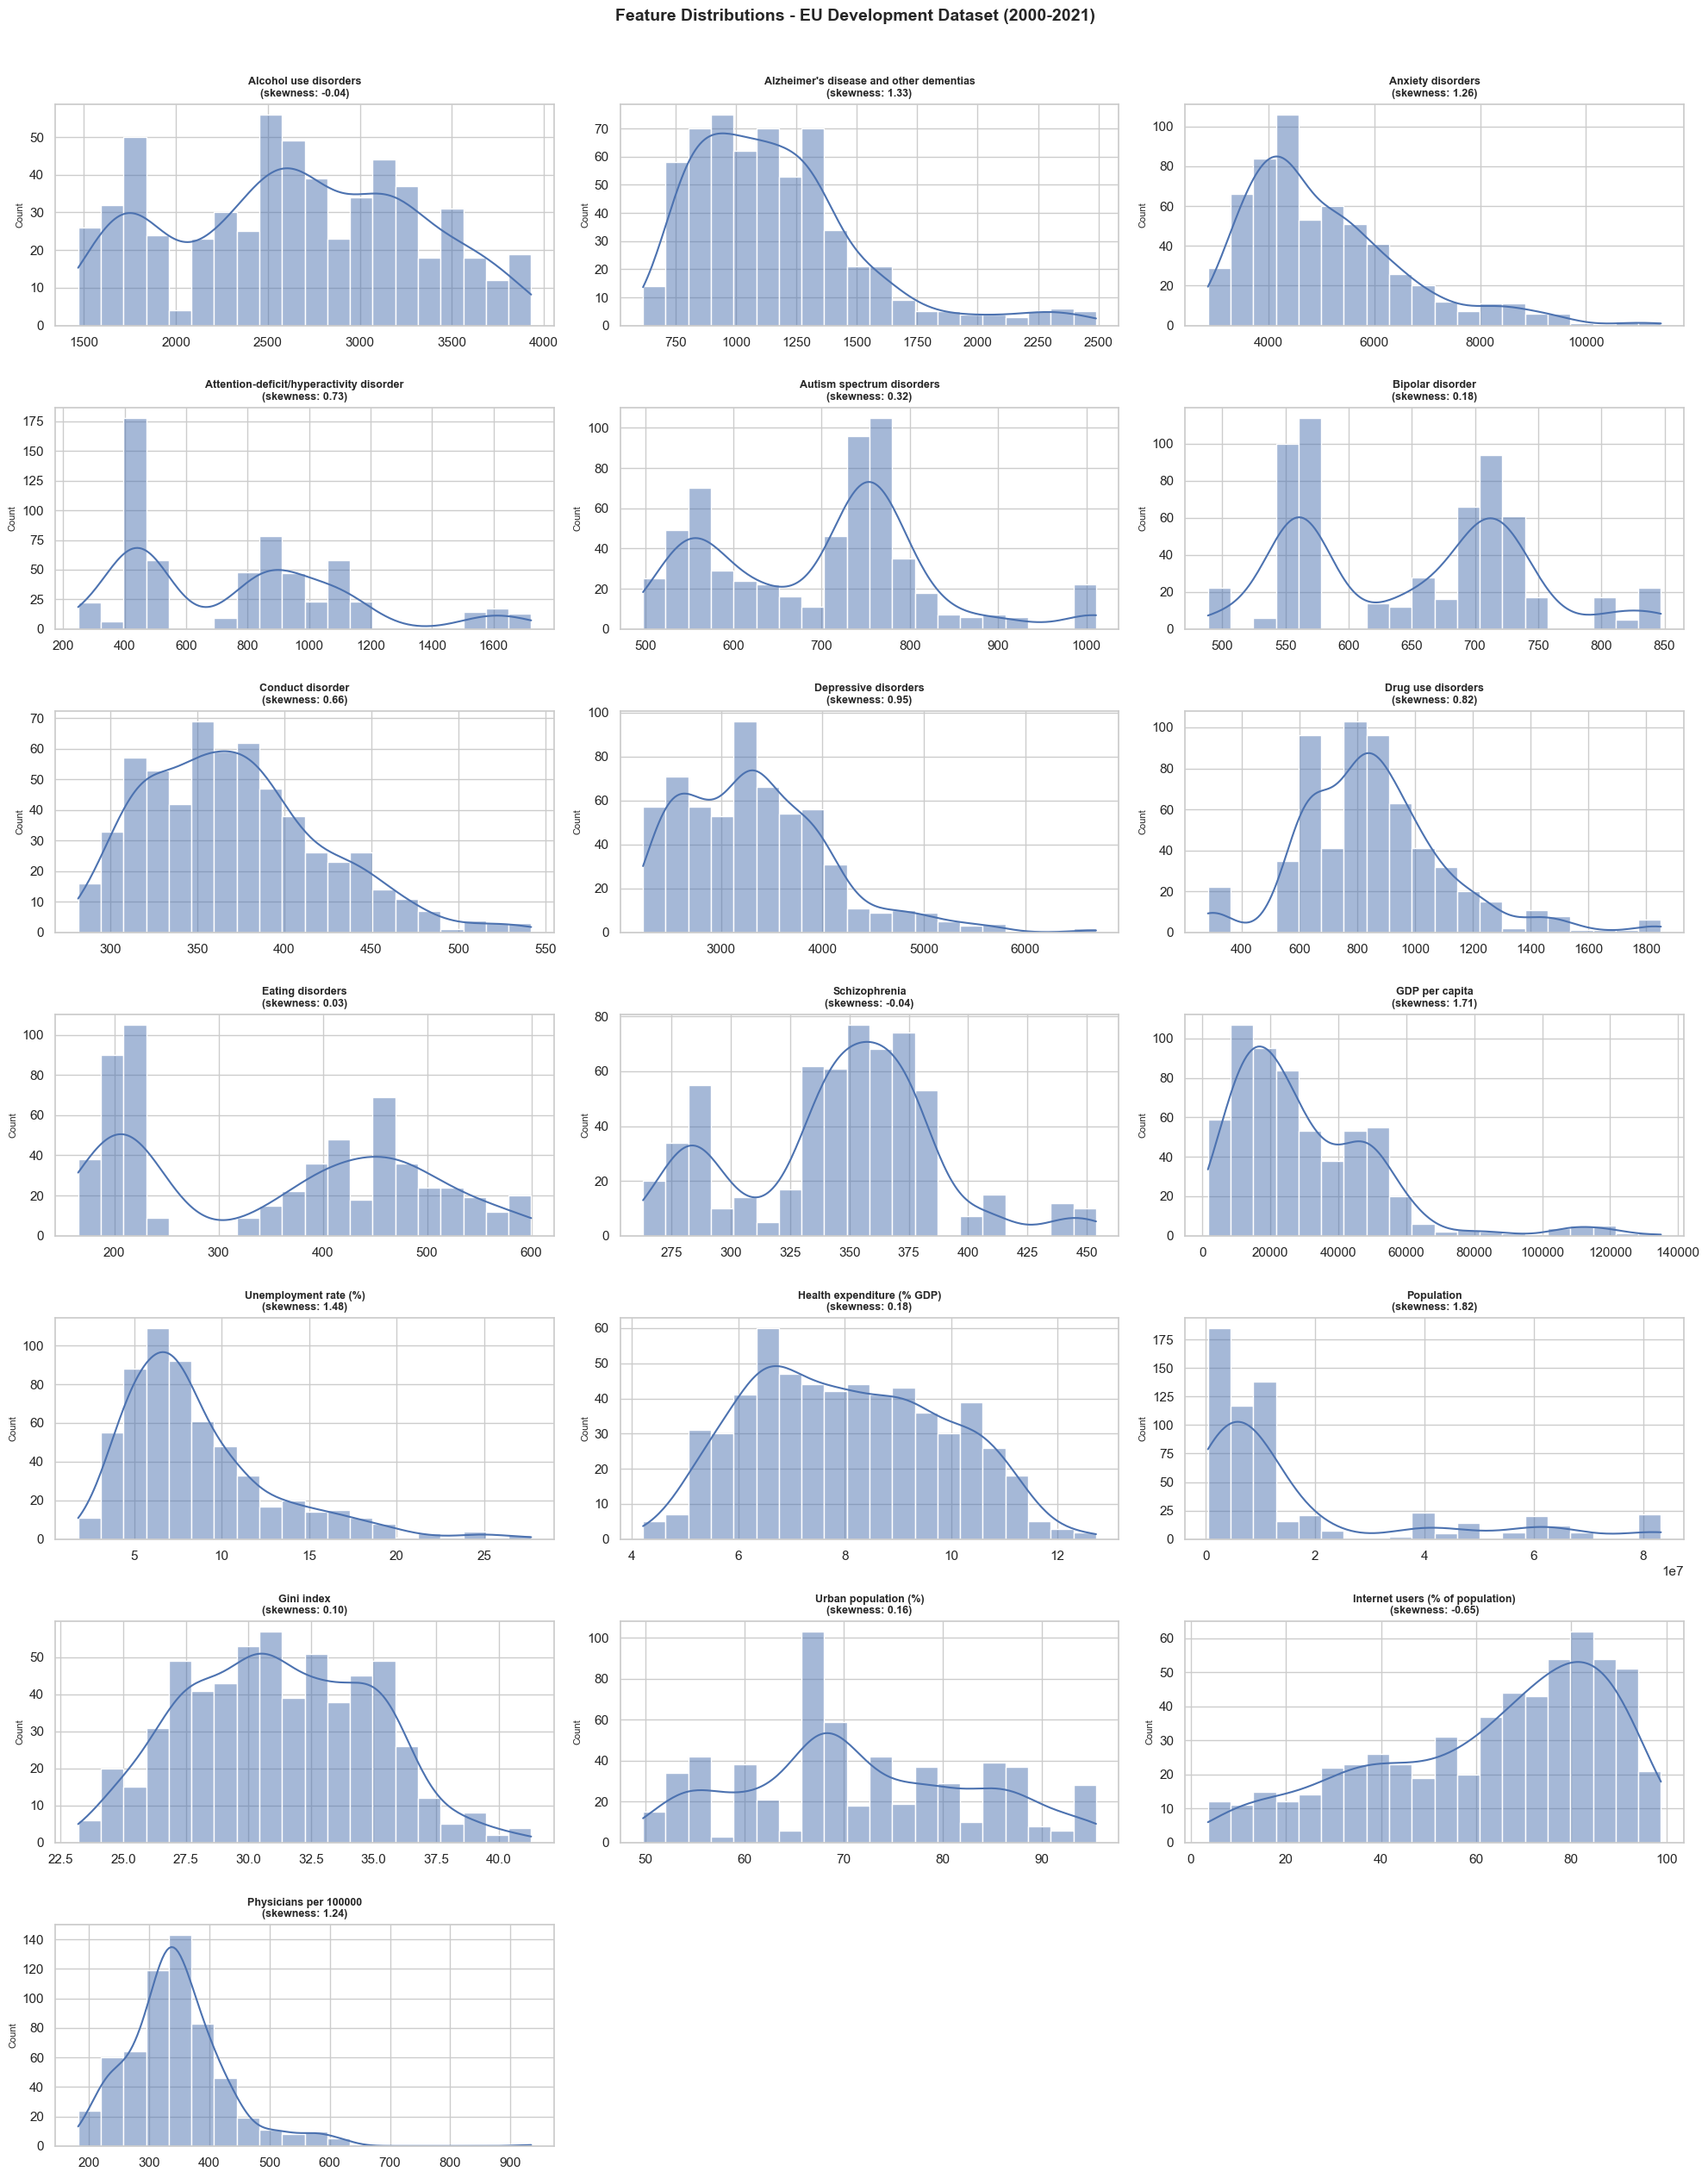


Skewness summary:
Population                                  1.82
GDP per capita                              1.71
Unemployment rate (%)                       1.48
Alzheimer's disease and other dementias     1.33
Anxiety disorders                           1.26
Physicians per 100000                       1.24
Depressive disorders                        0.95
Drug use disorders                          0.82
Attention-deficit/hyperactivity disorder    0.73
Conduct disorder                            0.66
Autism spectrum disorders                   0.32
Health expenditure (% GDP)                  0.18
Bipolar disorder                            0.18
Urban population (%)                        0.16
Gini index                                  0.10
Eating disorders                            0.03
Alcohol use disorders                      -0.04
Schizophrenia                              -0.04
Internet users (% of population)           -0.65
dtype: float64


In [ ]:
# ==============================================================================
# FEATURE DISTRIBUTION ANALYSIS
# Histograms + KDE for all numerical features to identify skewness
# ==============================================================================

predictor_features = [c for c in df_development.columns if c not in ID_COLS + [TARGET]]

ncols = 3
nrows = (len(predictor_features) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(20, 25))
axes = axes.flatten()

for i, col in enumerate(predictor_features):
    ax = axes[i]
    data_col = df_development[col].dropna()
    sns.histplot(data_col, kde=True, ax=ax, color="#4C72B0", bins=20)
    skew_val = data_col.skew()
    ax.set_title(f"{col}\n(skewness: {skew_val:.2f})", fontsize=9, fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("Count", fontsize=8)

for j in range(len(predictor_features), len(axes)):
    axes[j].set_visible(False)

plt.suptitle(
    "Feature Distributions - EU Development Dataset (2000-2021)",
    fontsize=14,
    fontweight="bold",
    y=1.01,
)
plt.tight_layout()
plt.show()

print("\nSkewness summary:")
print(df_development[predictor_features].skew().sort_values(ascending=False).round(2))

## Outlier detection

Outlier Summary (IQR method, threshold=1.5):


,Feature,Outlier count,Outlier %,Lower bound,Upper bound
4,Population,110,18.52,-16125106.75,35771617.25
2,Unemployment rate (%),31,5.22,-1.35,17.25
6,Physicians per 100000,26,4.38,163.24,517.34
0,Suicide rate,23,3.87,-2.05,30.30
1,GDP per capita,18,3.03,-28443.29,85443.25
3,Health expenditure (% GDP),0,0.00,2.28,13.70
5,Urban population (%),0,0.00,36.69,106.22
7,Gini index,0,0.00,19.41,42.91
8,Internet users (% of population),0,0.00,-13.00,140.16


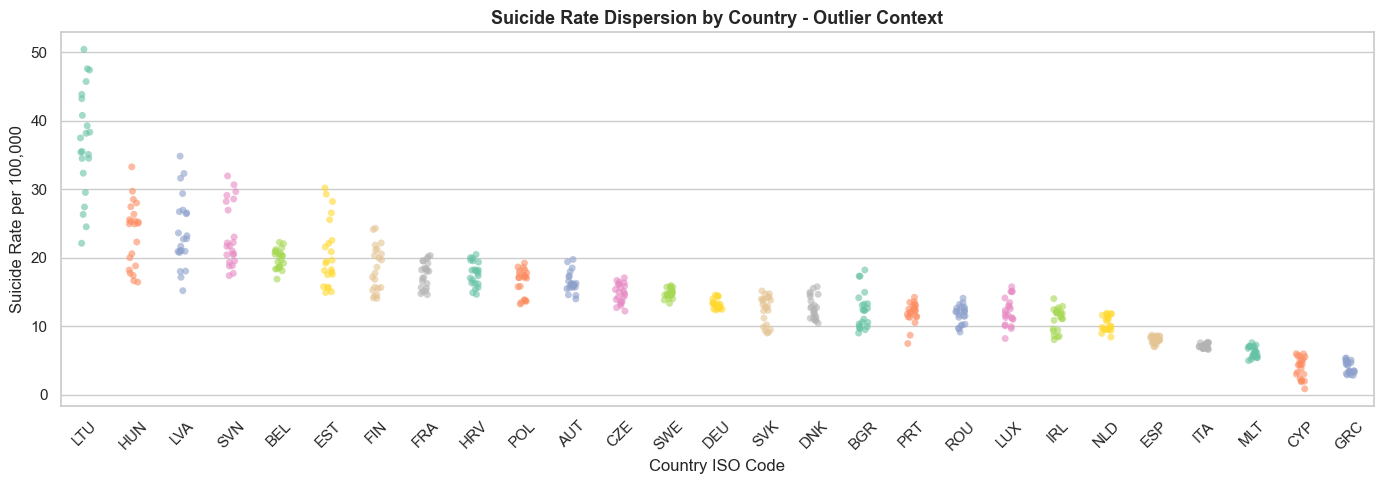

In [ ]:
# ==============================================================================
# OUTLIER DETECTION (IQR-based)
# ==============================================================================


def flag_outliers_iqr(df, columns, threshold=1.5):
    """
    Flags rows as outliers using the IQR method for the specified columns.

    Parameters:
    -----------
    df : pd.DataFrame
    columns : list of str
        Columns to check for outliers.
    threshold : float
        IQR multiplier (1.5 = standard, 3.0 = extreme only).

    Returns:
    --------
    pd.DataFrame with count and percentage of outlier rows per feature.
    """
    results = []
    for col in columns:
        if col not in df.columns:
            continue
        q1 = df[col].quantile(0.25)
        q3 = df[col].quantile(0.75)
        iqr = q3 - q1
        lower = q1 - threshold * iqr
        upper = q3 + threshold * iqr
        mask = (df[col] < lower) | (df[col] > upper)
        results.append(
            {
                "Feature": col,
                "Outlier count": mask.sum(),
                "Outlier %": round(mask.sum() / len(df) * 100, 2),
                "Lower bound": round(lower, 2),
                "Upper bound": round(upper, 2),
            }
        )
    return pd.DataFrame(results).sort_values("Outlier count", ascending=False)


socioeconomic_cols_for_outliers = [
    c for c in social_economic_features if c in df_development.columns
]

outlier_summary = flag_outliers_iqr(df_development, socioeconomic_cols_for_outliers)
print("Outlier Summary (IQR method, threshold=1.5):")
display(outlier_summary)

# Stripplot to visually contextualise suicide rate outliers by country
fig, ax = plt.subplots(figsize=(14, 5))
sns.stripplot(
    data=df_development,
    x="Code",
    y="Suicide rate",
    order=df_development.groupby("Code")["Suicide rate"]
    .median()
    .sort_values(ascending=False)
    .index,
    jitter=True,
    alpha=0.6,
    palette="Set2",
    ax=ax,
)
ax.set_title(
    "Suicide Rate Dispersion by Country - Outlier Context",
    fontsize=13,
    fontweight="bold",
)
ax.set_xlabel("Country ISO Code")
ax.set_ylabel("Suicide Rate per 100,000")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

## Multicollinearity check

Variance Inflation Factor (VIF) - Full predictor set:


,Feature,VIF
0,Eating disorders,12.082971
1,Attention-deficit/hyperactivity disorder,6.098285
2,Autism spectrum disorders,5.789120
3,GDP per capita,5.672588
4,Alzheimer's disease and other dementias,3.932731
5,Health expenditure (% GDP),3.755601
6,Bipolar disorder,3.648373
7,Internet users (% of population),3.100497
8,Urban population (%),3.091083
9,Conduct disorder,2.927916


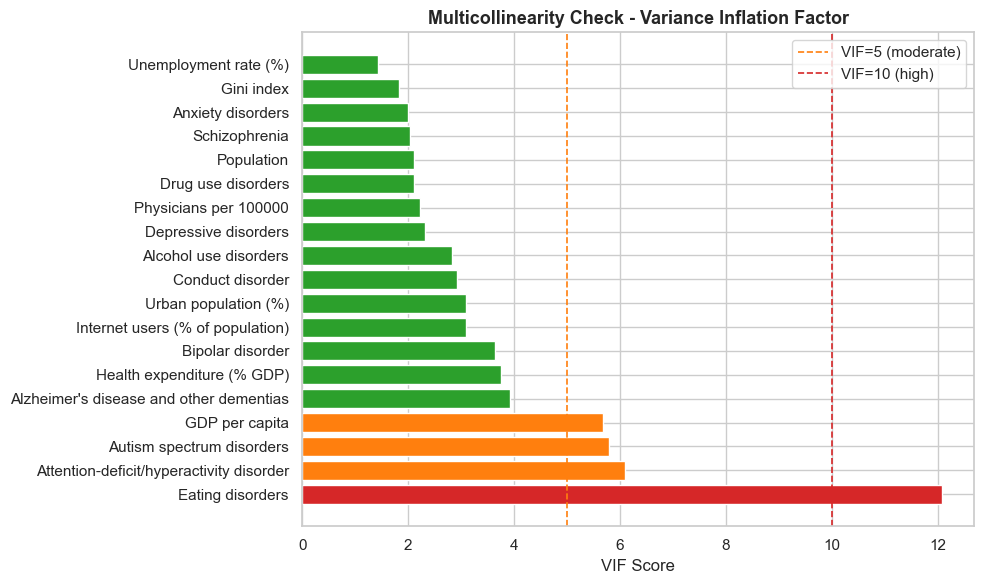

In [ ]:
# ==============================================================================
# MULTICOLLINEARITY CHECK (Variance Inflation Factor)
# VIF > 5: moderate concern; VIF > 10: high concern
# ==============================================================================


def compute_vif(df, feature_cols):
    """
    Computes the Variance Inflation Factor (VIF) for each predictor.
    High VIF indicates multicollinearity with other predictors.
    """
    X = df[feature_cols].dropna()
    X_const = add_constant(X)
    vif_data = (
        pd.DataFrame(
            {
                "Feature": X.columns,
                "VIF": [
                    variance_inflation_factor(X_const.values, i + 1)
                    for i in range(len(X.columns))
                ],
            }
        )
        .sort_values("VIF", ascending=False)
        .reset_index(drop=True)
    )
    return vif_data


vif_results = compute_vif(df_development, predictor_features)
print("Variance Inflation Factor (VIF) - Full predictor set:")
display(vif_results)

fig, ax = plt.subplots(figsize=(10, 6))
colors = [
    "#d62728" if v > 10 else "#ff7f0e" if v > 5 else "#2ca02c"
    for v in vif_results["VIF"]
]
ax.barh(vif_results["Feature"], vif_results["VIF"], color=colors)
ax.axvline(
    x=5, color="#ff7f0e", linestyle="--", linewidth=1.2, label="VIF=5 (moderate)"
)
ax.axvline(x=10, color="#d62728", linestyle="--", linewidth=1.2, label="VIF=10 (high)")
ax.set_xlabel("VIF Score")
ax.set_title(
    "Multicollinearity Check - Variance Inflation Factor",
    fontsize=13,
    fontweight="bold",
)
ax.legend()
plt.tight_layout()
plt.show()

### Addressing high multicollinearity: dropping Eating disorders
Since there is a value with high VIF, meaning it shares so much variance with other predictors that it adds almost no independent information to the model, it is decided to drop 'Eating disorders'

Variance Inflation Factor (VIF) - Full predictor set:


,Feature,VIF
0,Autism spectrum disorders,5.006914
1,Attention-deficit/hyperactivity disorder,4.622119
2,Alzheimer's disease and other dementias,3.891740
3,Health expenditure (% GDP),3.755597
4,GDP per capita,3.272651
5,Urban population (%),3.086496
6,Conduct disorder,2.922833
7,Internet users (% of population),2.915365
8,Bipolar disorder,2.867809
9,Alcohol use disorders,2.687695


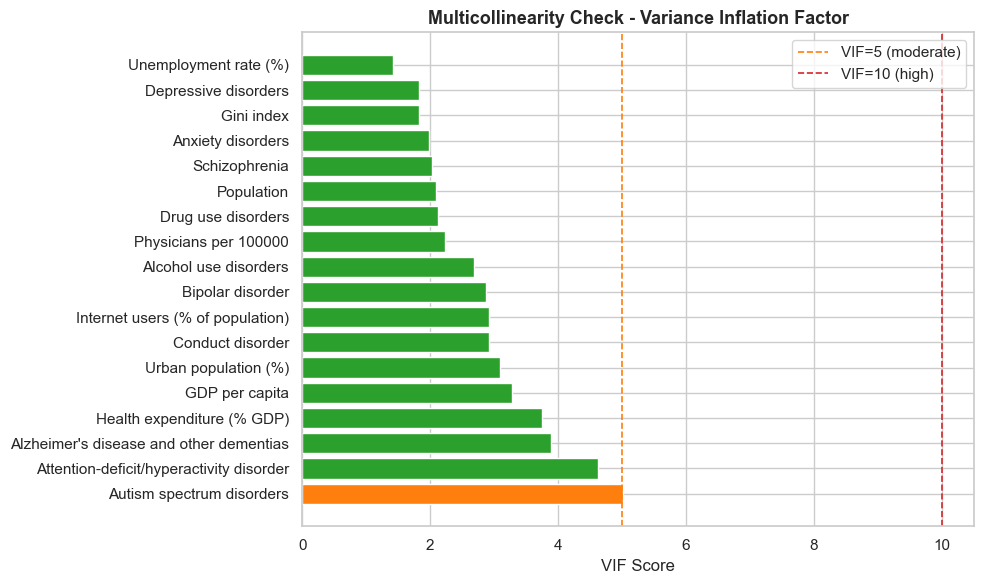

In [ ]:
df_development.drop(columns=["Eating disorders"], inplace=True)
predictor_features = [c for c in df_development.columns if c not in ID_COLS + [TARGET]]

vif_results = compute_vif(df_development, predictor_features)
print("Variance Inflation Factor (VIF) - Full predictor set:")
display(vif_results)

fig, ax = plt.subplots(figsize=(10, 6))
colors = [
    "#d62728" if v > 10 else "#ff7f0e" if v > 5 else "#2ca02c"
    for v in vif_results["VIF"]
]
ax.barh(vif_results["Feature"], vif_results["VIF"], color=colors)
ax.axvline(
    x=5, color="#ff7f0e", linestyle="--", linewidth=1.2, label="VIF=5 (moderate)"
)
ax.axvline(x=10, color="#d62728", linestyle="--", linewidth=1.2, label="VIF=10 (high)")
ax.set_xlabel("VIF Score")
ax.set_title(
    "Multicollinearity Check - Variance Inflation Factor",
    fontsize=13,
    fontweight="bold",
)
ax.legend()
plt.tight_layout()
plt.show()

## Two approaches:
- Option A. Geographical division. In this approach, we take 70% of the countries for training, and we try to predict "unknown" countries with what we learnt from those countries. This way we want to be able to predict the suicide rates of a country only knowing their socioeconomic and health data.
- Option B. Time division. In this approach, we take 70% of the years for all countries for training, and we try to predict the suicide rate in the upcoming years.

The development dataset (2000–2021) is used for both approaches.
Years 2022–2023 are excluded as WHO suicide rate data is unavailable for that period.

### OPTION A - Geographical division

In [ ]:
np.random.shuffle(EU_countries_iso)

# Division 70% Train, 15% Test, 15% Validation (countries)
total_countries = len(EU_countries_iso)
train_split = int(total_countries * 0.70)
test_split = int(total_countries * 0.85)

train_countries = EU_countries_iso[:train_split]
test_countries = EU_countries_iso[train_split:test_split]
val_countries = EU_countries_iso[test_split:]

# Creating the subsets for Option A
df_train_A = df_development[df_development["Code"].isin(train_countries)].copy()
df_test_A = df_development[df_development["Code"].isin(test_countries)].copy()
df_val_A = df_development[df_development["Code"].isin(val_countries)].copy()

print(f"Train countries ({len(train_countries)}): {train_countries}")
print(f"Test  countries ({len(test_countries)}):  {test_countries}")
print(f"Val   countries ({len(val_countries)}):   {val_countries}")
print(
    f"\nTrain: {len(df_train_A)} rows | Test: {len(df_test_A)} rows | Val: {len(df_val_A)} rows"
)
display(df_train_A.head(3))

Train countries (18): ['SVK', 'BGR', 'LUX', 'IRL', 'ROU', 'DNK', 'EST', 'GRC', 'HUN', 'FRA', 'ITA', 'AUT', 'POL', 'FIN', 'SVN', 'NLD', 'DEU', 'HRV']
Test  countries (4):  ['ESP', 'CZE', 'CYP', 'MLT']
Val   countries (5):   ['PRT', 'LTU', 'LVA', 'SWE', 'BEL']

Train: 396 rows | Test: 88 rows | Val: 110 rows


,Country,Code,Year,Alcohol use disorders,Alzheimer's disease and other dementias,Anxiety disorders,Attention-deficit/hyperactivity disorder,Autism spectrum disorders,Bipolar disorder,Conduct disorder,Depressive disorders,Drug use disorders,Schizophrenia,GDP per capita,Unemployment rate (%),Health expenditure (% GDP),Population,Gini index,Urban population (%),Internet users (% of population),Physicians per 100000,Suicide rate,Region
0,Austria,AUT,2000,3191.951091,1132.966544,4024.482195,1175.534494,721.252486,720.168715,395.555429,2408.933392,881.662224,340.766068,24487.297469,4.687,9.389345,8011566.0,29.000000,66.769024,33.730133,387.6,19.753390,Western Europe/Nordics
1,Austria,AUT,2001,3193.762279,1143.969355,4046.938653,1173.433463,723.015405,719.736433,394.027233,2414.230764,875.548127,342.045193,24430.495983,4.007,9.452435,8042293.0,29.166667,66.840816,39.185450,398.9,18.508048,Western Europe/Nordics
2,Austria,AUT,2002,3196.670699,1158.019381,4069.554739,1173.688637,724.906163,717.163393,390.398108,2420.619752,867.476203,343.374835,26334.862215,4.852,9.591399,8081957.0,29.333333,66.888746,36.560000,406.0,19.413281,Western Europe/Nordics


Correlation matrices are computed exclusively on the training set to prevent any information from the test or validation sets influencing the EDA.

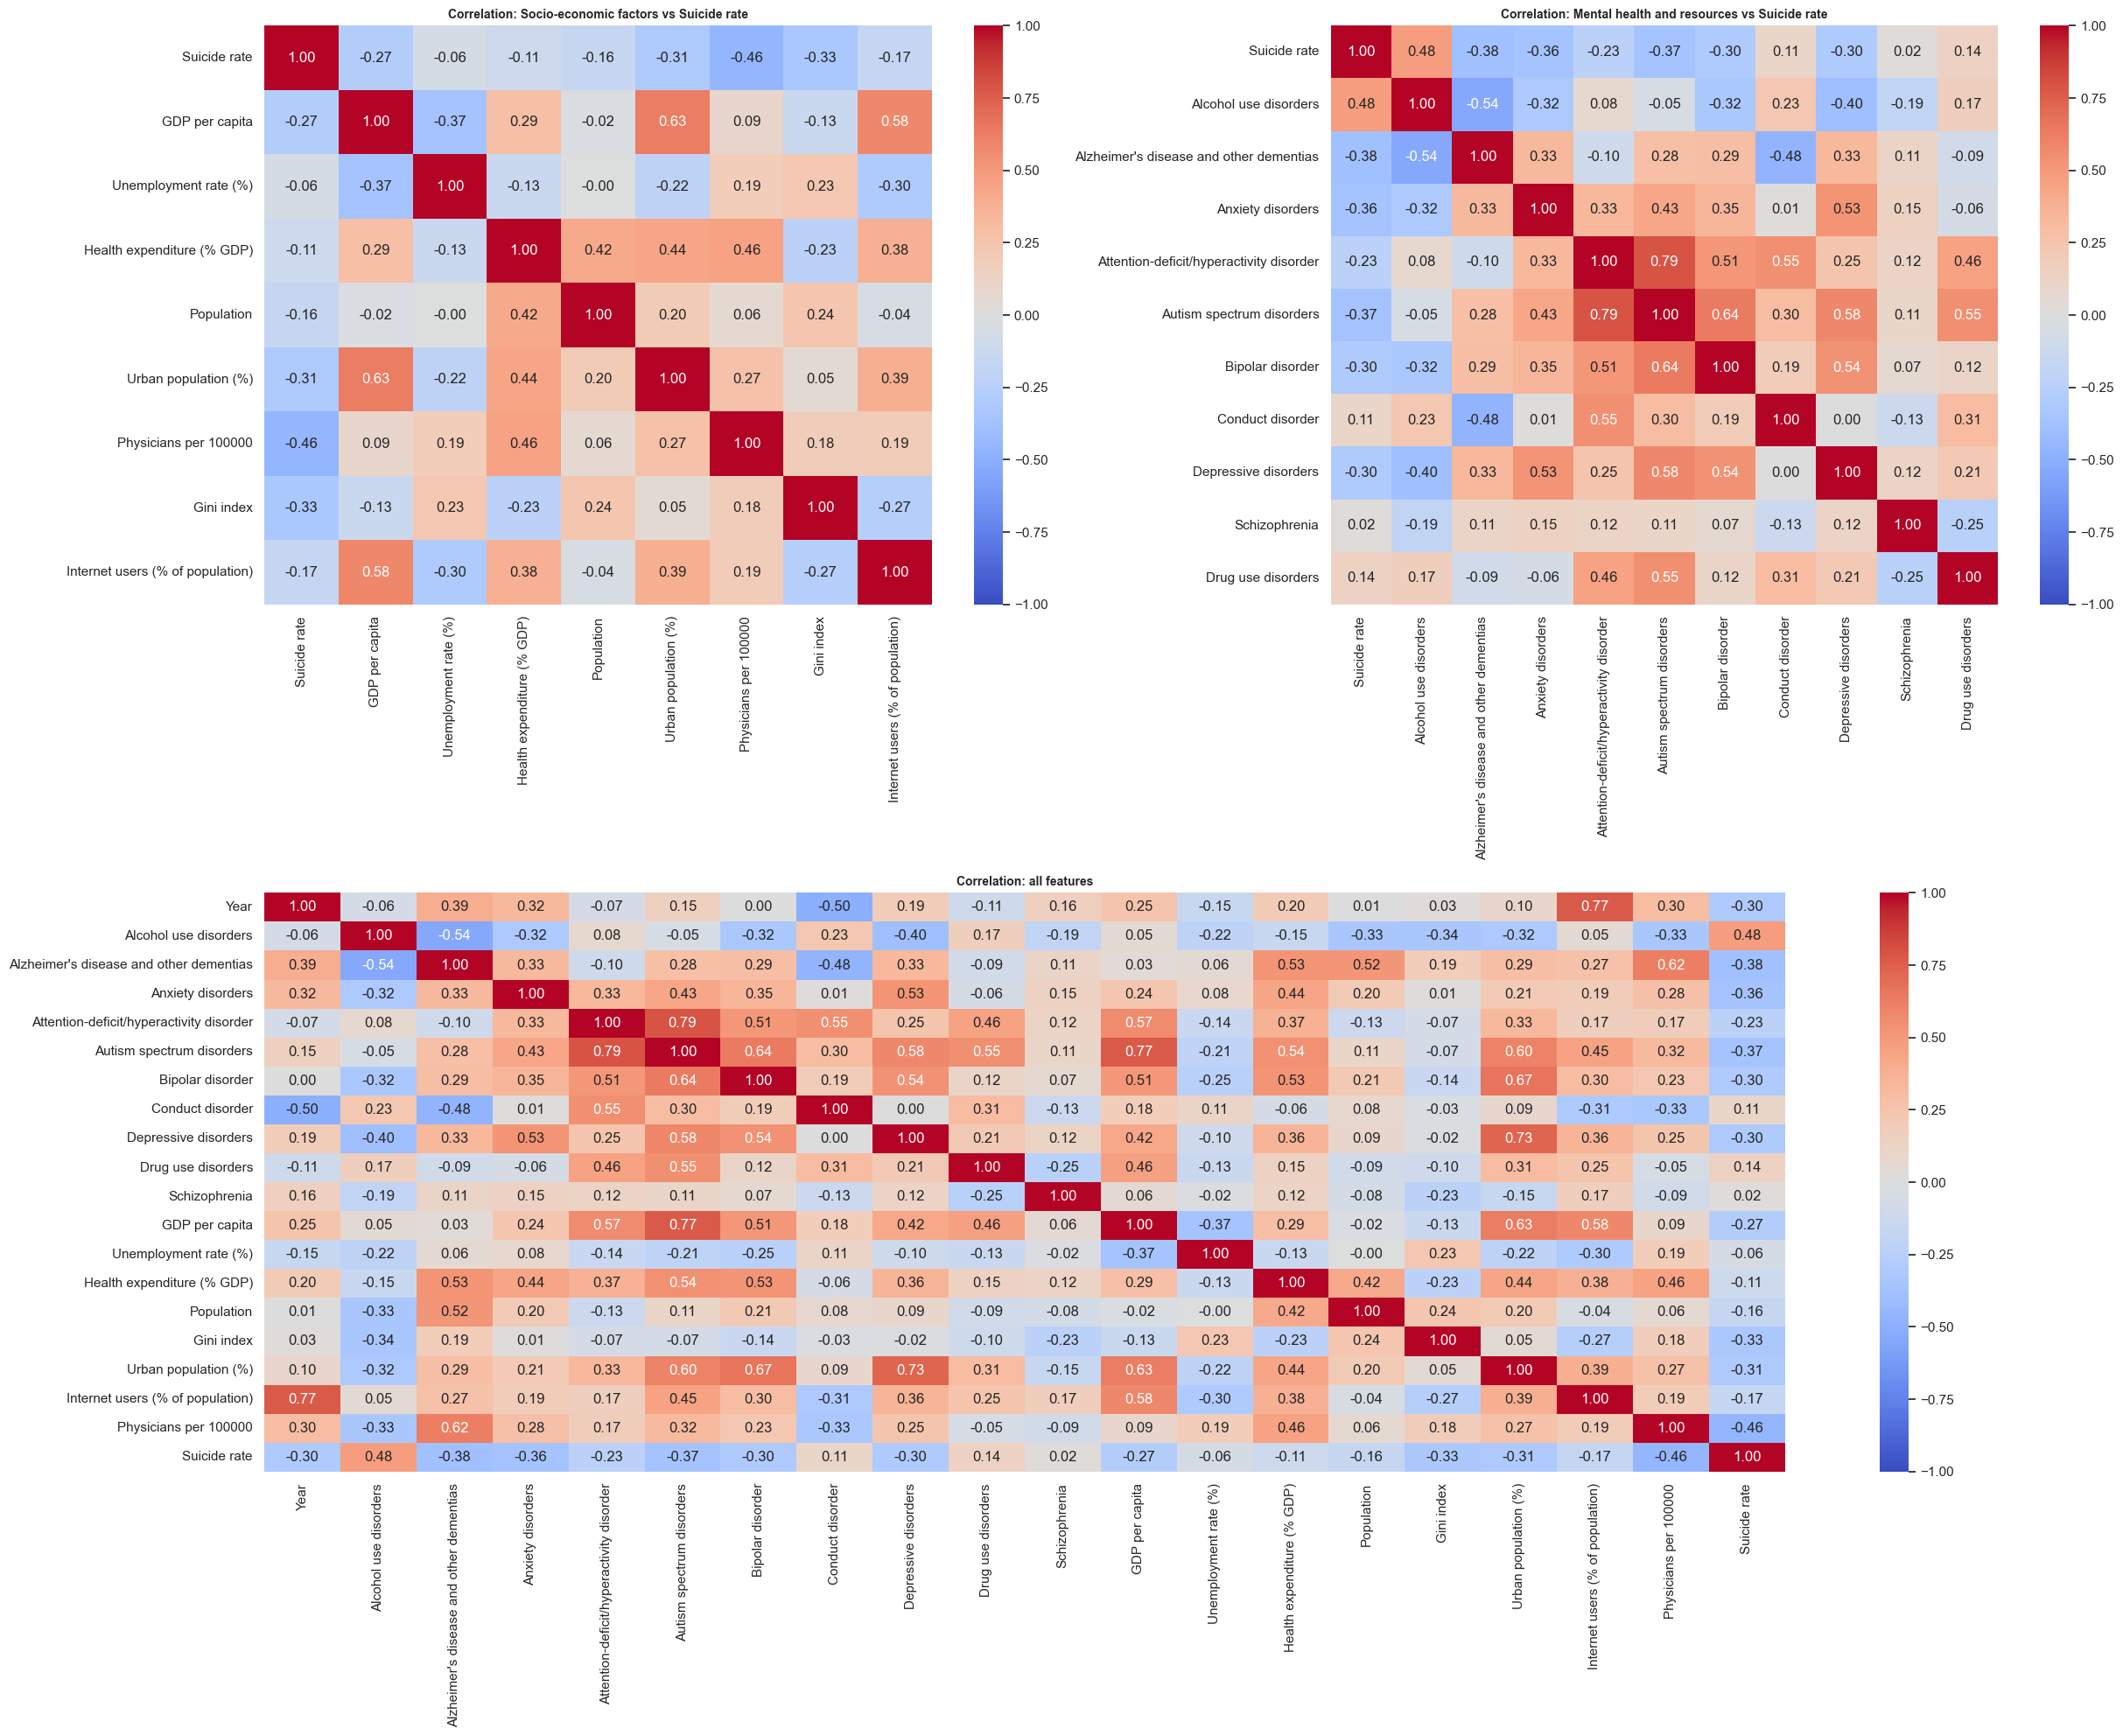

In [ ]:
# ==============================================================================
# CORRELATION ANALYSIS
# Computed on training set only to prevent data leakage into test/val
# ==============================================================================

fig, axs = plt.subplot_mosaic(
    [["top_left", "top_right"], ["bottom", "bottom"]], figsize=(25, 20)
)
sns.heatmap(
    df_train_A[social_economic_features].corr(),
    ax=axs["top_left"],
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
)
axs["top_left"].set_title(
    "Correlation: Socio-economic factors vs Suicide rate",
    fontsize=10,
    fontweight="bold",
)

sns.heatmap(
    df_train_A[health_related_features].corr(),
    ax=axs["top_right"],
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
)
axs["top_right"].set_title(
    "Correlation: Mental health and resources vs Suicide rate",
    fontsize=10,
    fontweight="bold",
)

corr_matrix = df_train_A.select_dtypes(include=[np.number]).corr()
sns.heatmap(
    corr_matrix,
    ax=axs["bottom"],
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
)
axs["bottom"].set_title(
    "Correlation: all features",
    fontsize=10,
    fontweight="bold",
)

plt.tight_layout()
plt.show()

### Feature scaling for set A

In [ ]:
# ==============================================================================
# Scaling the data. Using RobustScaler because as described before, the dataset
# contains several outliers and therefore using the median and IQR will not be
# affected by extreme values.
# ==============================================================================

# Option A: fit on train_A, transform test_A and val_A
scaler_A = RobustScaler()

X_train_A = df_train_A[predictor_features].copy()
X_test_A = df_test_A[predictor_features].copy()
X_val_A = df_val_A[predictor_features].copy()

y_train_A = df_train_A[TARGET].copy()
y_test_A = df_test_A[TARGET].copy()
y_val_A = df_val_A[TARGET].copy()

X_train_A_scaled = pd.DataFrame(
    scaler_A.fit_transform(X_train_A),
    columns=predictor_features,
    index=X_train_A.index,
)
X_test_A_scaled = pd.DataFrame(
    scaler_A.transform(X_test_A),
    columns=predictor_features,
    index=X_test_A.index,
)
X_val_A_scaled = pd.DataFrame(
    scaler_A.transform(X_val_A),
    columns=predictor_features,
    index=X_val_A.index,
)

print(" OPTION A - Scaled dataset shapes")
print(f"X_train_A: {X_train_A_scaled.shape}  |  y_train_A: {y_train_A.shape}")
print(f"X_test_A:  {X_test_A_scaled.shape}   |  y_test_A:  {y_test_A.shape}")
print(f"X_val_A:   {X_val_A_scaled.shape}    |  y_val_A:   {y_val_A.shape}")
display(X_train_A_scaled.describe().T.round(3))

# Sanity check: after RobustScaler, median should be ~0 and IQR should be ~1 on train
print("\nScaling sanity check (train A) — median ~0, IQR ~1:")
sanity_A = pd.DataFrame(
    {
        "Median": X_train_A_scaled.median().round(3),
        "IQR": (
            X_train_A_scaled.quantile(0.75) - X_train_A_scaled.quantile(0.25)
        ).round(3),
    }
)
display(sanity_A)

 OPTION A - Scaled dataset shapes
X_train_A: (396, 18)  |  y_train_A: (396,)
X_test_A:  (88, 18)   |  y_test_A:  (88,)
X_val_A:   (110, 18)    |  y_val_A:   (110,)


,count,mean,std,min,25%,50%,75%,max
Alcohol use disorders,396.0,0.008,0.698,-1.280,-0.436,0.0,0.564,1.401
Alzheimer's disease and other dementias,396.0,0.190,0.915,-1.106,-0.451,-0.0,0.549,3.238
Anxiety disorders,396.0,0.154,0.760,-1.101,-0.405,0.0,0.595,3.272
Attention-deficit/hyperactivity disorder,396.0,0.153,0.569,-0.632,-0.335,-0.0,0.665,1.641
Autism spectrum disorders,396.0,-0.110,0.560,-0.993,-0.672,0.0,0.328,1.193
Bipolar disorder,396.0,-0.020,0.557,-0.981,-0.526,0.0,0.474,1.100
Conduct disorder,396.0,0.062,0.699,-1.210,-0.496,0.0,0.504,2.507
Depressive disorders,396.0,0.137,0.802,-0.912,-0.501,0.0,0.499,3.584
Drug use disorders,396.0,0.007,0.846,-1.920,-0.534,-0.0,0.466,2.371
Schizophrenia,396.0,-0.025,1.171,-3.141,-0.556,0.0,0.444,3.083



Scaling sanity check (train A) — median ~0, IQR ~1:


,Median,IQR
Alcohol use disorders,0.0,1.0
Alzheimer's disease and other dementias,-0.0,1.0
Anxiety disorders,0.0,1.0
Attention-deficit/hyperactivity disorder,-0.0,1.0
Autism spectrum disorders,0.0,1.0
Bipolar disorder,0.0,1.0
Conduct disorder,0.0,1.0
Depressive disorders,0.0,1.0
Drug use disorders,-0.0,1.0
Schizophrenia,0.0,1.0


### OPTION B - Time division
All 27 countries are included across all splits. The model learns temporal patterns from earlier years and is evaluated on its ability to generalise to more recent periods.

In [ ]:
# Division 70% Train, 15% Test, 15% Validation (years)
year_range = sorted(df_development["Year"].unique())
total_years = len(year_range)
train_split = int(total_years * 0.70)
test_split = int(total_years * 0.85)

train_years = year_range[:train_split]
test_years = year_range[train_split:test_split]
val_years = year_range[test_split:]

# Creating the subsets for Option B
df_train_B = df_development[df_development["Year"].isin(train_years)].copy()
df_test_B = df_development[df_development["Year"].isin(test_years)].copy()
df_val_B = df_development[df_development["Year"].isin(val_years)].copy()

print(f"Train years: {train_years}")
print(f"Test  years: {test_years}")
print(f"Val   years: {val_years}")
print(
    f"\nTrain: {len(df_train_B)} rows | Test: {len(df_test_B)} rows | Val: {len(df_val_B)} rows"
)
display(df_train_B.head(3))

Train years: [np.int64(2000), np.int64(2001), np.int64(2002), np.int64(2003), np.int64(2004), np.int64(2005), np.int64(2006), np.int64(2007), np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014)]
Test  years: [np.int64(2015), np.int64(2016), np.int64(2017)]
Val   years: [np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021)]

Train: 405 rows | Test: 81 rows | Val: 108 rows


,Country,Code,Year,Alcohol use disorders,Alzheimer's disease and other dementias,Anxiety disorders,Attention-deficit/hyperactivity disorder,Autism spectrum disorders,Bipolar disorder,Conduct disorder,Depressive disorders,Drug use disorders,Schizophrenia,GDP per capita,Unemployment rate (%),Health expenditure (% GDP),Population,Gini index,Urban population (%),Internet users (% of population),Physicians per 100000,Suicide rate,Region
0,Austria,AUT,2000,3191.951091,1132.966544,4024.482195,1175.534494,721.252486,720.168715,395.555429,2408.933392,881.662224,340.766068,24487.297469,4.687,9.389345,8011566.0,29.000000,66.769024,33.730133,387.6,19.753390,Western Europe/Nordics
1,Austria,AUT,2001,3193.762279,1143.969355,4046.938653,1173.433463,723.015405,719.736433,394.027233,2414.230764,875.548127,342.045193,24430.495983,4.007,9.452435,8042293.0,29.166667,66.840816,39.185450,398.9,18.508048,Western Europe/Nordics
2,Austria,AUT,2002,3196.670699,1158.019381,4069.554739,1173.688637,724.906163,717.163393,390.398108,2420.619752,867.476203,343.374835,26334.862215,4.852,9.591399,8081957.0,29.333333,66.888746,36.560000,406.0,19.413281,Western Europe/Nordics


Correlation matrices are computed exclusively on the training set to prevent any information from the test or validation sets influencing the EDA.

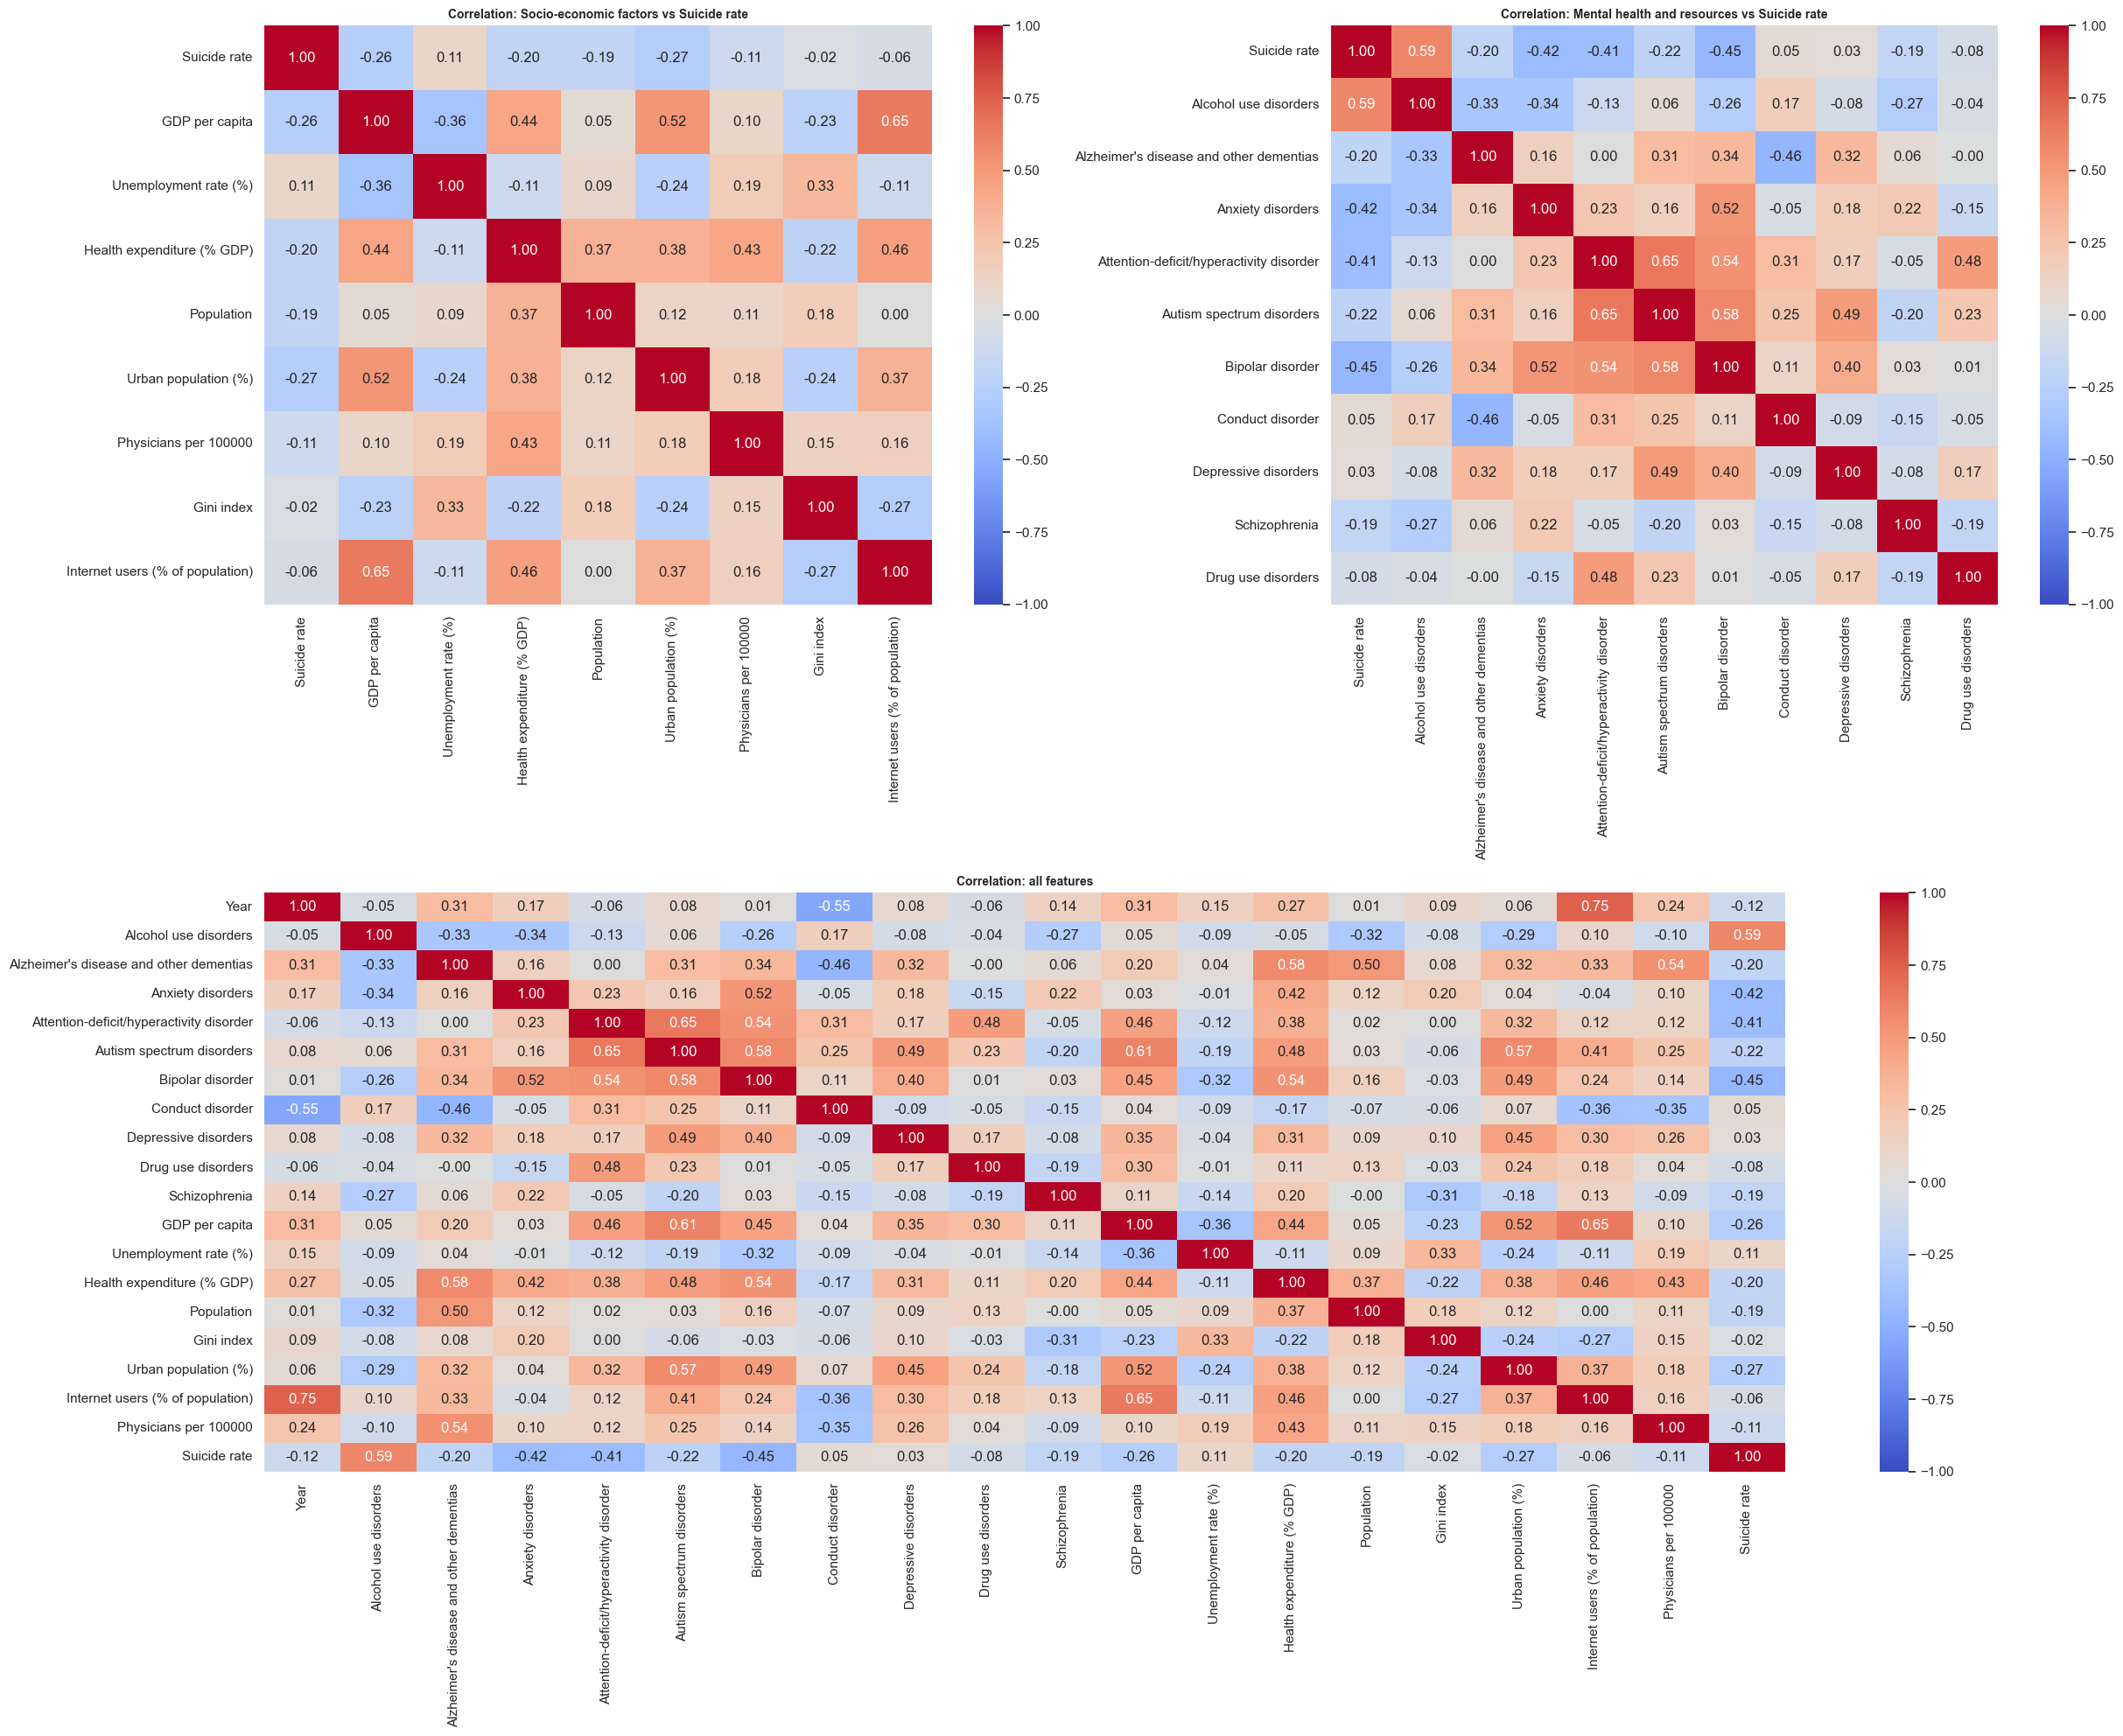

In [ ]:
# ==============================================================================
# CORRELATION ANALYSIS FOR SET B
# Computed on training set only to prevent data leakage into test/val
# ==============================================================================

fig, axs = plt.subplot_mosaic(
    [["top_left", "top_right"], ["bottom", "bottom"]], figsize=(25, 20)
)
sns.heatmap(
    df_train_B[social_economic_features].corr(),
    ax=axs["top_left"],
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
)
axs["top_left"].set_title(
    "Correlation: Socio-economic factors vs Suicide rate",
    fontsize=10,
    fontweight="bold",
)

sns.heatmap(
    df_train_B[health_related_features].corr(),
    ax=axs["top_right"],
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
)
axs["top_right"].set_title(
    "Correlation: Mental health and resources vs Suicide rate",
    fontsize=10,
    fontweight="bold",
)

corr_matrix = df_train_B.select_dtypes(include=[np.number]).corr()
sns.heatmap(
    corr_matrix,
    ax=axs["bottom"],
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
)
axs["bottom"].set_title(
    "Correlation: all features",
    fontsize=10,
    fontweight="bold",
)

plt.tight_layout()
plt.show()

### Feature scaling for set B

In [ ]:
# ==============================================================================
# Scaling the data. Using RobustScaler because as described before, the dataset
# contains several outliers and therefore using the median and IQR will not be
# affected by extreme values.
# ==============================================================================

# Option B: fit on train_B, transform test_B and val_B
scaler_B = RobustScaler()

X_train_B = df_train_B[predictor_features].copy()
X_test_B = df_test_B[predictor_features].copy()
X_val_B = df_val_B[predictor_features].copy()

y_train_B = df_train_B[TARGET].copy()
y_test_B = df_test_B[TARGET].copy()
y_val_B = df_val_B[TARGET].copy()

X_train_B_scaled = pd.DataFrame(
    scaler_B.fit_transform(X_train_B),
    columns=predictor_features,
    index=X_train_B.index,
)
X_test_B_scaled = pd.DataFrame(
    scaler_B.transform(X_test_B),
    columns=predictor_features,
    index=X_test_B.index,
)
X_val_B_scaled = pd.DataFrame(
    scaler_B.transform(X_val_B),
    columns=predictor_features,
    index=X_val_B.index,
)

print(" OPTION B - Scaled dataset shapes")
print(f"X_train_B: {X_train_B_scaled.shape}  |  y_train_B: {y_train_B.shape}")
print(f"X_test_B:  {X_test_B_scaled.shape}   |  y_test_B:  {y_test_B.shape}")
print(f"X_val_B:   {X_val_B_scaled.shape}    |  y_val_B:   {y_val_B.shape}")
display(X_train_B_scaled.describe().T.round(3))

# Sanity check: after RobustScaler, median should be ~0 and IQR should be ~1 on train
print("\nScaling sanity check (train B) — median ~0, IQR ~1:")
sanity_B = pd.DataFrame(
    {
        "Median": X_train_B_scaled.median().round(3),
        "IQR": (
            X_train_B_scaled.quantile(0.75) - X_train_B_scaled.quantile(0.25)
        ).round(3),
    }
)
display(sanity_B)

 OPTION B - Scaled dataset shapes
X_train_B: (405, 18)  |  y_train_B: (405,)
X_test_B:  (81, 18)   |  y_test_B:  (81,)
X_val_B:   (108, 18)    |  y_val_B:   (108,)


,count,mean,std,min,25%,50%,75%,max
Alcohol use disorders,405.0,-0.002,0.657,-1.215,-0.474,0.0,0.526,1.197
Alzheimer's disease and other dementias,405.0,0.167,0.785,-1.054,-0.434,0.0,0.566,3.163
Anxiety disorders,405.0,0.213,0.795,-1.013,-0.364,0.0,0.636,2.994
Attention-deficit/hyperactivity disorder,405.0,-0.089,0.661,-1.057,-0.681,0.0,0.319,1.633
Autism spectrum disorders,405.0,-0.189,0.621,-1.195,-0.841,0.0,0.159,1.508
Bipolar disorder,405.0,-0.124,0.582,-1.178,-0.698,0.0,0.302,1.135
Conduct disorder,405.0,0.054,0.791,-1.549,-0.486,0.0,0.514,2.529
Depressive disorders,405.0,0.006,0.690,-1.058,-0.560,0.0,0.440,2.324
Drug use disorders,405.0,0.068,0.886,-1.921,-0.541,0.0,0.459,3.414
Schizophrenia,405.0,-0.108,0.936,-1.943,-0.534,0.0,0.466,2.410



Scaling sanity check (train B) — median ~0, IQR ~1:


,Median,IQR
Alcohol use disorders,0.0,1.0
Alzheimer's disease and other dementias,0.0,1.0
Anxiety disorders,0.0,1.0
Attention-deficit/hyperactivity disorder,0.0,1.0
Autism spectrum disorders,0.0,1.0
Bipolar disorder,0.0,1.0
Conduct disorder,0.0,1.0
Depressive disorders,0.0,1.0
Drug use disorders,0.0,1.0
Schizophrenia,0.0,1.0
